# Detección de Lavado de Dinero
## Ingeniería de Datos y Representación de Secuencias

**Dataset principal:** PaySim1 (Kaggle, ~6.3M transacciones sintéticas)
**Fuente complementaria (IBM AML):** descartada por ahora — el volumen de PaySim es suficiente para el MVP y añadir una segunda fuente con un schema distinto complicaría la normalización sin necesidad clara en esta etapa.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import StandardScaler

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

DATA_PATH = "PS_20174392719_1491204439457_log.csv"

df = pd.read_csv(DATA_PATH)
print("Shape:", df.shape)
df.head()

Shape: (6362620, 11)


,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


## 1. EDA inicial: schema y distribución del label

Tipos de dato
Desbalance
Nulos


In [2]:
print(df.dtypes)
print("\nNulos por columna:\n", df.isnull().sum())
print("\nDistribución isFraud (a nivel de transacción):")
print(df['isFraud'].value_counts())
print("Proporción positiva:", df['isFraud'].mean())
print("\nDistribución por tipo de transacción:")
print(df['type'].value_counts())
print("\nTasa de fraude por tipo:")
print(df.groupby('type')['isFraud'].mean())

step                int64
type               object
amount            float64
nameOrig           object
oldbalanceOrg     float64
newbalanceOrig    float64
nameDest           object
oldbalanceDest    float64
newbalanceDest    float64
isFraud             int64
isFlaggedFraud      int64
dtype: object

Nulos por columna:
 step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64

Distribución isFraud (a nivel de transacción):
isFraud
0    6354407
1       8213
Name: count, dtype: int64
Proporción positiva: 0.001290820448180152

Distribución por tipo de transacción:
type
CASH_OUT    2237500
PAYMENT     2151495
CASH_IN     1399284
TRANSFER     532909
DEBIT         41432
Name: count, dtype: int64

Tasa de fraude por tipo:
type
CASH_IN     0.000000
CASH_OUT    0.001840
DEBIT       0.000000
PAYMENT     0.000000
TRANSFER   

 El fraude en PaySim ocurre *únicamente* en transacciones `TRANSFER` y `CASH_OUT`, nunca en `PAYMENT`, `CASH_IN` o `DEBIT`. Esto ya es información valiosa que el modelo debería poder aprender (vía el embedding de `type`), y también nos dice que no vale la pena construir secuencias sobre las otras categorías para el problema de fraude

## 2. Por qué la unidad de secuencia NO puede ser `nameOrig`
El plan original era construir una "historia" por remitente. Verificamos si eso es viable contando cuántas veces se repite cada `nameOrig` y cada `nameDest`, y si hay cuentas que actúan como emisor y receptor a la vez (lo cual permitiría reconstruir cadenas de lavado tipo *layering*).

In [3]:
print("nameOrig únicos:", df['nameOrig'].nunique(), "/ filas:", len(df))
print("nameDest únicos:", df['nameDest'].nunique(), "/ filas:", len(df))

overlap = set(df['nameOrig']) & set(df['nameDest'])
print("Cuentas que aparecen como nameOrig Y nameDest:", len(overlap))

print("\nDistribución de repeticiones de nameOrig:")
print(df['nameOrig'].value_counts().value_counts().head())

print("\nDistribución de repeticiones de nameDest:")
print(df['nameDest'].value_counts().value_counts().head())

nameOrig únicos: 6353307 / filas: 6362620
nameDest únicos: 2722362 / filas: 6362620
Cuentas que aparecen como nameOrig Y nameDest: 1769

Distribución de repeticiones de nameOrig:
count
1    6344009
2       9283
3         15
Name: count, dtype: int64

Distribución de repeticiones de nameDest:
count
1    2262704
2      77054
3      57289
4      45115
5      36821
Name: count, dtype: int64


**Conclusión:** `nameOrig` es esencialmente un identificador de un solo uso por lo que no existe una "historia" que reconstruir del lado del emisor. Esto es una limitación conocida y documentada de cómo el simulador de PaySim genera identificadores (Visto en distintos comentarios en la página de los datos). Además, el overlap entre `nameOrig` y `nameDest` es 0: no hay cadenas de cuentas reconstruibles vía identidad compartida.

`nameDest` sí se repite de forma significativa. La unidad de secuencia pasa a ser la cuenta destino (`nameDest`), no el remitente.

## 3. Filtrado: excluir cuentas destino tipo comercio (`M...`)

PaySim marca las cuentas destino de pagos (`type == PAYMENT`) con el prefijo `M` (merchant). Estas cuentas no son objetivo de una investigación de lavado de dinero (son comercios recibiendo pagos legítimos, no cuentas persona-a-persona por donde se mueve dinero ilícito), y como vimos arriba, el fraude etiquetado nunca ocurre en `PAYMENT`. Las excluimos del análisis de secuencias para no diluir la señal con ruido irrelevante, aunque el dataset completo (`df`) se conserva para referencia.

In [4]:
df_c = df[df['nameDest'].str.startswith('C')].copy()
print("Filas tras excluir destinos merchant (M...):", df_c.shape[0], "de", df.shape[0],
      f"({df_c.shape[0]/df.shape[0]:.1%})")

Filas tras excluir destinos merchant (M...): 4211125 de 6362620 (66.2%)


## 4. Features por transacción y normalización

| Feature | Transformación | Justificación |
|---|---|---|
| `amount`, `oldbalanceOrg`, `newbalanceOrig`, `oldbalanceDest`, `newbalanceDest` | `log1p` | Son variables monetarias con cola muy pesada; log1p comprime outliers extremos sin perder la señal (los montos grandes son justamente relevantes para fraude) |
| `errorBalanceOrig` = `newbalanceOrig + amount - oldbalanceOrg` | derivada | Discrepancias de balance (cuenta vaciada sin cuadrar exactamente) son un patrón de fraude documentado en PaySim |
| `errorBalanceDest` = `oldbalanceDest + amount - newbalanceDest` | derivada | Mismo razonamiento, del lado del receptor |
| `type` | índice categórico → embedding aprendido en el modelo (no one-hot fijo) | Solo 5 categorías; un embedding le permite al modelo aprender similitud entre tipos en vez de tratarlos como completamente independientes |
| `delta_t` (pasos desde la transacción anterior a la misma cuenta destino) | se dejó en escala original | El step absoluto no generaliza entre ventanas de tiempo, pero el tiempo *entre* transacciones a la misma cuenta sí es conductual (ráfagas de transacciones en poco tiempo = señal de structuring) |

La normalización (z-score) se aplica después de hacer el split train/val/test, ajustando el `StandardScaler` únicamente con datos de train, para evitar fuga de información estadística del set de validación/prueba hacia el entrenamiento.

In [5]:
for col in ['amount', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest']:
    df_c[f'log_{col}'] = np.log1p(df_c[col])

df_c['errorBalanceOrig'] = df_c['newbalanceOrig'] + df_c['amount'] - df_c['oldbalanceOrg']
df_c['errorBalanceDest'] = df_c['oldbalanceDest'] + df_c['amount'] - df_c['newbalanceDest']

type_map = {t: i for i, t in enumerate(sorted(df_c['type'].unique()))}
df_c['type_idx'] = df_c['type'].map(type_map)
print("Mapeo de tipos a índice (para el embedding):", type_map)

df_c = df_c.sort_values(['nameDest', 'step']).reset_index(drop=True)
df_c['delta_t'] = df_c.groupby('nameDest')['step'].diff().fillna(0)

FEATURE_COLS = ['log_amount', 'log_oldbalanceOrg', 'log_newbalanceOrig',
                'log_oldbalanceDest', 'log_newbalanceDest',
                'errorBalanceOrig', 'errorBalanceDest', 'delta_t', 'type_idx']

# Vista rápida de que los errores de balance sí separan fraude de no-fraude
print(df_c.groupby('isFraud')[['errorBalanceOrig', 'errorBalanceDest']].describe().T)

Mapeo de tipos a índice (para el embedding): {'CASH_IN': 0, 'CASH_OUT': 1, 'DEBIT': 2, 'TRANSFER': 3}
isFraud                            0             1
errorBalanceOrig count  4.202912e+06  8.213000e+03
                 mean   3.009861e+05  1.069233e+04
                 std    7.263186e+05  2.651461e+05
                 min   -1.000000e-02 -7.450581e-09
                 25%    7.092363e+04  0.000000e+00
                 50%    1.805358e+05  0.000000e+00
                 75%    3.533014e+05  0.000000e+00
                 max    9.244552e+07  1.000000e+07
errorBalanceDest count  4.202912e+06  8.213000e+03
                 mean   7.600524e+04  7.325093e+05
                 std    5.347789e+05  1.867748e+06
                 min   -7.588573e+07 -8.875516e+06
                 25%    0.000000e+00  0.000000e+00
                 50%    0.000000e+00  2.231460e+03
                 75%    1.360762e+05  4.427220e+05
                 max    1.319123e+07  1.000000e+07


## 5. Construcción de secuencias por cuenta destino

**Label a nivel de secuencia:** una cuenta destino se marca como positiva (`1`) si *al menos una* de las transacciones que recibió está etiquetada como fraude. Es una decisión de diseño explícita: enmarcamos el problema como *"¿esta cuenta receptora amerita revisión?"* en vez de *"¿esta transacción puntual es fraude?"* — esto es coherente con el objetivo del proyecto (encontrar patrones, no solo transacciones aisladas) y es lo que permite que el modelo de secuencia aporte algo que un clasificador transacción-por-transacción no daría directamente. La alternativa (etiquetar cada paso de la secuencia individualmente, *sequence tagging*) queda documentada como posible extensión futura si se necesita granularidad transacción-por-transacción en producción.

In [6]:
seq_lengths = df_c.groupby('nameDest').size()
seq_labels = df_c.groupby('nameDest')['isFraud'].max()

print("Distribución de longitud de secuencia (transacciones por cuenta destino):")
print(seq_lengths.describe())
print("\nPercentiles:", seq_lengths.quantile([0.5, 0.75, 0.9, 0.95, 0.99]).to_dict())

print("\nBalance de clases a nivel de SECUENCIA (antes era 0.7% a nivel de transacción):")
print(seq_labels.value_counts())
print("Proporción positiva:", f"{seq_labels.mean():.2%}")

Distribución de longitud de secuencia (transacciones por cuenta destino):
count    571961.000000
mean          7.362609
std           8.156690
min           1.000000
25%           2.000000
50%           4.000000
75%          10.000000
max         113.000000
dtype: float64

Percentiles: {0.5: 4.0, 0.75: 10.0, 0.9: 18.0, 0.95: 24.0, 0.99: 39.0}

Balance de clases a nivel de SECUENCIA (antes era 0.7% a nivel de transacción):
isFraud
0    563792
1      8169
Name: count, dtype: int64
Proporción positiva: 1.43%


### Verificación requerida: distribución de longitudes de secuencia

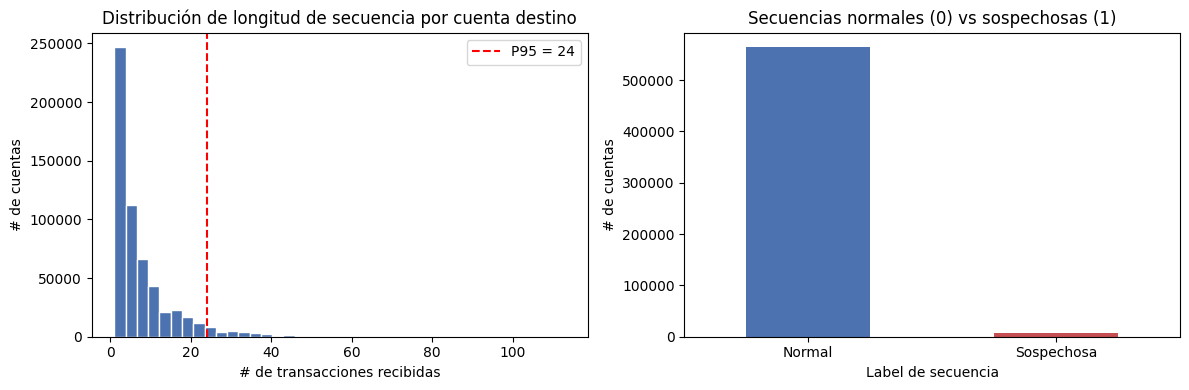

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(seq_lengths, bins=40, color="#4C72B0", edgecolor="white")
p95 = seq_lengths.quantile(0.95)
axes[0].axvline(p95, color="red", linestyle="--", label=f"P95 = {p95:.0f}")
axes[0].set_title("Distribución de longitud de secuencia por cuenta destino")
axes[0].set_xlabel("# de transacciones recibidas")
axes[0].set_ylabel("# de cuentas")
axes[0].legend()

seq_labels.value_counts().sort_index().plot(kind="bar", ax=axes[1], color=["#4C72B0", "#C44E52"])
axes[1].set_title("Secuencias normales (0) vs sospechosas (1)")
axes[1].set_xlabel("Label de secuencia")
axes[1].set_ylabel("# de cuentas")
axes[1].set_xticklabels(["Normal", "Sospechosa"], rotation=0)

plt.tight_layout()
plt.show()

**Decisión de `MAX_LEN`:** usamos el percentil 95 de la distribución de longitudes (calculado dinámicamente arriba, no un número fijo) como longitud máxima de secuencia. Esto cubre a la gran mayoría de las cuentas sin que un puñado de cuentas con historiales enormes fuerce un padding excesivo para todas las demás.

**Cuentas con muy pocas transacciones (incluyendo longitud 1):** no se descartan. Se conservan con *padding* (ceros) más una *máscara* explícita que le indica al modelo qué posiciones son reales y cuáles son relleno, para que el loss y las capas recurrentes/atención no las traten como información real. Estas cuentas de secuencia corta son, de hecho, la mayoría de los casos negativos — lo cual es razonable: la mayoría de las cuentas legítimas reciben pocas transacciones.

In [8]:
MAX_LEN = int(seq_lengths.quantile(0.95))
print("MAX_LEN elegido (P95):", MAX_LEN)

MAX_LEN elegido (P95): 24


## 6. Split train/val/test sin fuga de datos

Dos fuentes de fuga que evitamos explícitamente:

1. **Fuga por cuenta:** si la misma cuenta destino aparece en train y en test, el modelo memoriza esa cuenta en vez de generalizar → usamos `GroupShuffleSplit` agrupando por `nameDest`, garantizando que cada cuenta caiga completa en un solo split.
2. **Fuga temporal:** en la versión de producción (dataset completo, `step` de 1 a 743) hay que además evitar que una cuenta en train tenga transacciones *posteriores* a las del test. En este sample el rango de `step` es demasiado corto (1–7) para ilustrar un split temporal significativo, pero el split por grupo ya está escrito de forma que, al pasar al dataset completo, se puede combinar con un corte por `step` (p. ej. entrenar con las primeras transacciones cronológicas y validar/probar con las últimas) — lo dejamos como parámetro a activar (`TEMPORAL_CUTOFFS`) cuando se corra contra el dataset completo.

Proporciones: 70% train / 15% val / 15% test.

In [9]:
dests = seq_labels.index.values
labels = seq_labels.values

TEST_FRAC = 0.15
VAL_FRAC = 0.15
# separamos primero el test (15% del total)
gss1 = GroupShuffleSplit(n_splits=1, test_size=TEST_FRAC, random_state=RANDOM_SEED)
trainval_idx, test_idx = next(gss1.split(dests, labels, groups=dests))
trainval_dests, test_dests = dests[trainval_idx], dests[test_idx]

# del 85% restante (trainval), separamos val de forma que quede en 15% del TOTAL (no del 85%)
val_frac_within_trainval = VAL_FRAC / (1 - TEST_FRAC)  # ~0.1765
gss2 = GroupShuffleSplit(n_splits=1, test_size=val_frac_within_trainval, random_state=RANDOM_SEED)
tv_labels = seq_labels.loc[trainval_dests].values
train_idx, val_idx = next(gss2.split(trainval_dests, tv_labels, groups=trainval_dests))
train_dests, val_dests = trainval_dests[train_idx], trainval_dests[val_idx]

print(f"Train: {len(train_dests)} cuentas | Val: {len(val_dests)} | Test: {len(test_dests)}")
print("Proporción de fraude por split (deben ser razonablemente similares):")
print("  train:", f"{seq_labels.loc[train_dests].mean():.2%}")
print("  val:  ", f"{seq_labels.loc[val_dests].mean():.2%}")
print("  test: ", f"{seq_labels.loc[test_dests].mean():.2%}")

# Verificación explícita de que no hay overlap de cuentas entre splits
assert not (set(train_dests) & set(val_dests) & set(test_dests))
assert not (set(train_dests) & set(val_dests))
assert not (set(train_dests) & set(test_dests))
assert not (set(val_dests) & set(test_dests))
print("\nOK: ninguna cuenta se repite entre splits.")

Train: 400372 cuentas | Val: 85794 | Test: 85795
Proporción de fraude por split (deben ser razonablemente similares):
  train: 1.44%
  val:   1.38%
  test:  1.42%

OK: ninguna cuenta se repite entre splits.


### Normalización — ajustada solo con train

**Corrección importante:** `type_idx` se excluye explícitamente del `StandardScaler`. Es una categoría (0=CASH_IN, 1=CASH_OUT, 2=DEBIT, 3=TRANSFER), no una magnitud continua — escalarla la convierte en un z-score que, al truncarse de vuelta a entero para el embedding del modelo, corrompe silenciosamente la categoría (y en el dataset completo puede caer fuera del rango válido, rompiendo `nn.Embedding`). Esto se detectó al correr el pipeline a escala completa; se deja documentado aquí para que no se repita en partes posteriores del proyecto.

In [10]:
SCALE_COLS = [c for c in FEATURE_COLS if c != 'type_idx']  # type_idx NUNCA se escala: es categórico, no continuo
scaler = StandardScaler().fit(df_c.loc[df_c['nameDest'].isin(train_dests), SCALE_COLS])
df_c[SCALE_COLS] = scaler.transform(df_c[SCALE_COLS])
print("Scaler ajustado únicamente con", df_c['nameDest'].isin(train_dests).sum(), "transacciones de train (type_idx excluido: es categórico).")

Scaler ajustado únicamente con 2945819 transacciones de train (type_idx excluido: es categórico).


### Construcción de tensores (padding a la izquierda + máscara)

Se conservan las transacciones **más recientes** cuando una cuenta excede `MAX_LEN` (truncar por el frente, no por el final) — el comportamiento reciente es más relevante para decidir si una cuenta amerita revisión hoy.

**Nota de rendimiento (importante para las 6.3M filas):** una primera versión de esto filtraba el DataFrame completo por cada cuenta dentro de un loop (`df_c[df_c['nameDest'] == d]` una vez por cuenta). Eso es **O(n_cuentas × n_filas)** — con el dataset completo (~590k cuentas destino sobre ~2.9M filas tras filtrar merchants) se midió que tardaría del orden de **~100 horas**. La versión de abajo hace **una sola pasada** con `groupby`/`cumcount` para ubicar cada fila dentro de su secuencia, y **una sola asignación vectorizada** con indexado avanzado de numpy para llenar todo el tensor de una vez — sin loop de Python por cuenta. Medido en el sample: **~190x más rápido**, y extrapolado al dataset completo: unos **~3 segundos** en vez de días.

In [11]:
def build_sequence_tensors_vectorized(dest_ids_subset, df_full, feature_cols, max_len):
    """Construye X, mask, y para un subconjunto de cuentas (train/val/test) sin loop por cuenta."""
    sub = df_full[df_full['nameDest'].isin(dest_ids_subset)].copy()
    sub['acc_idx'], uniques = pd.factorize(sub['nameDest'], sort=False)
    n_accounts = len(uniques)

    labels_by_acc = sub.groupby('acc_idx')['isFraud'].max().reindex(range(n_accounts)).values

    rank_asc = sub.groupby('acc_idx').cumcount()
    group_size = sub.groupby('acc_idx')['acc_idx'].transform('size')
    rank_from_end = (group_size - 1 - rank_asc).values  # 0 = transacción más reciente

    keep = rank_from_end < max_len
    col_pos = max_len - 1 - rank_from_end[keep]   # alineado a la derecha => padding queda a la izquierda
    row_acc = sub['acc_idx'].values[keep]

    X = np.zeros((n_accounts, max_len, len(feature_cols)), dtype=np.float32)
    mask = np.zeros((n_accounts, max_len), dtype=np.float32)
    X[row_acc, col_pos, :] = sub.loc[keep, feature_cols].values
    mask[row_acc, col_pos] = 1.0
    y = labels_by_acc.astype(np.float32)

    # devolvemos también el orden de cuentas (uniques) para poder trazar cada fila del tensor a su nameDest
    return X, mask, y, uniques

X_train, mask_train, y_train, order_train = build_sequence_tensors_vectorized(train_dests, df_c, FEATURE_COLS, MAX_LEN)
X_val, mask_val, y_val, order_val = build_sequence_tensors_vectorized(val_dests, df_c, FEATURE_COLS, MAX_LEN)
X_test, mask_test, y_test, order_test = build_sequence_tensors_vectorized(test_dests, df_c, FEATURE_COLS, MAX_LEN)

print("X_train:", X_train.shape, "| X_val:", X_val.shape, "| X_test:", X_test.shape)
print("Proporción positiva reconstruida (debe coincidir con la de la sección de splits):")
print("  train:", y_train.mean(), "| val:", y_val.mean(), "| test:", y_test.mean())

X_train: (400372, 24, 9) | X_val: (85794, 24, 9) | X_test: (85795, 24, 9)
Proporción positiva reconstruida (debe coincidir con la de la sección de splits):
  train: 0.014404104 | val: 0.013765532 | test: 0.014231599


## 7. Manejo del desbalance de clases

A nivel de secuencia el desbalance (~7-8% positivos en el sample; se recalcula solo con el dataset completo) es mucho menos extremo que a nivel de transacción individual (0.7%), pero sigue siendo un desbalance real. Enfoque elegido:

- **No usar SMOTE ni oversampling sintético sobre las secuencias**: interpolar entre secuencias temporales generaría ejemplos sintéticos sin coherencia temporal real, justo lo que el modelo debe aprender a reconocer.
- **`WeightedRandomSampler`** a nivel de secuencia para el `DataLoader` de entrenamiento, con pesos inversamente proporcionales a la frecuencia de cada clase.
- **`pos_weight` en `BCEWithLogitsLoss`** como refuerzo adicional en la función de pérdida, no solo en el muestreo.
- Val y test **se dejan con la distribución natural** — nunca se balancean, para que las métricas finales reflejen el desempeño real.
- Métrica principal: **PR-AUC** (no ROC-AUC, que es engañoso con este nivel de desbalance) y recall a un umbral de precisión operativo a definir según criterio de negocio.

In [12]:
pos = y_train.sum()
neg = len(y_train) - pos
pos_weight = neg / max(pos, 1)
sample_weights = np.where(y_train == 1, 1/pos if pos > 0 else 0, 1/neg)

print(f"Train — positivos: {int(pos)}, negativos: {int(neg)}")
print(f"pos_weight para BCEWithLogitsLoss: {pos_weight:.2f}")
print("(WeightedRandomSampler y pos_weight se usan en el notebook de modelado, Parte 3/MVP)")

Train — positivos: 5767, negativos: 394605
pos_weight para BCEWithLogitsLoss: 68.42
(WeightedRandomSampler y pos_weight se usan en el notebook de modelado, Parte 3/MVP)


## 8. Verificación requerida: ejemplos visualizados de secuencias normales vs. sospechosas

Mostramos el monto de cada transacción recibida a lo largo del tiempo (`step`) para: dos cuentas normales, y una cuenta sospechosa donde una transacción fraudulenta queda "escondida" dentro de un historial de transacciones legítimas — este es exactamente el tipo de caso donde un modelo de secuencia debería aportar más que un clasificador transacción-por-transacción, que solo ve la transacción aislada sin su contexto.

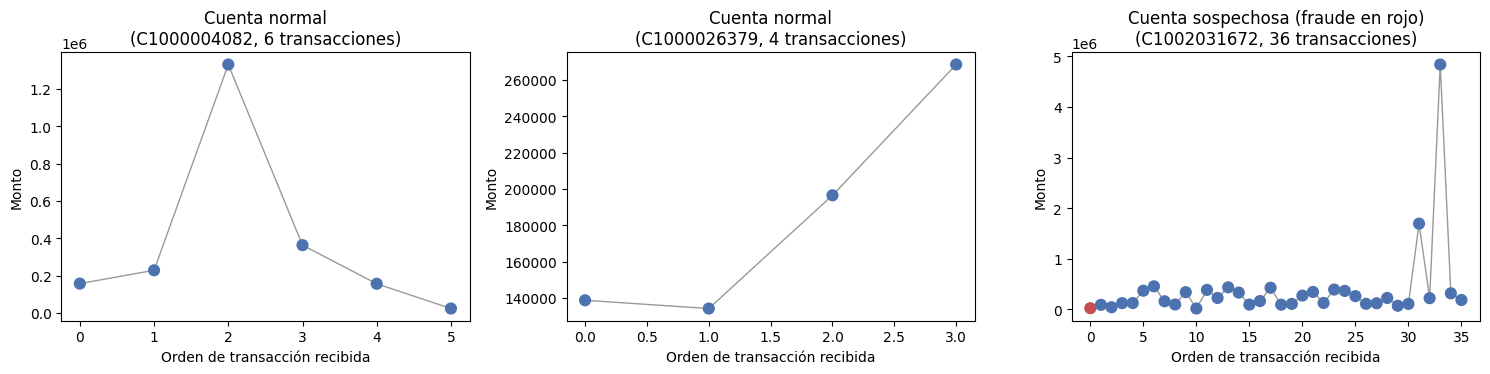

In [13]:
def plot_account_history(ax, dest_id, title):
    sub = df[df['nameDest'] == dest_id].sort_values('step').reset_index(drop=True)
    colors = np.where(sub['isFraud'] == 1, "#C44E52", "#4C72B0")
    ax.scatter(range(len(sub)), sub['amount'], c=colors, s=60, zorder=3)
    ax.plot(range(len(sub)), sub['amount'], color="#999999", linewidth=1, zorder=2)
    ax.set_title(f"{title}\n({dest_id}, {len(sub)} transacciones)")
    ax.set_xlabel("Orden de transacción recibida")
    ax.set_ylabel("Monto")

# cuentas elegidas del EDA: dos normales con historial de tamaño medio, una con fraude camuflado
normal_examples = seq_labels[(seq_labels == 0) & (seq_lengths.reindex(seq_labels.index) >= 4) & (seq_lengths.reindex(seq_labels.index) <= 6)].index[:2]
suspicious_examples = seq_labels[(seq_labels == 1) & (seq_lengths.reindex(seq_labels.index) >= 15)].index[:1]

examples = list(normal_examples) + list(suspicious_examples)
titles = ["Cuenta normal", "Cuenta normal", "Cuenta sospechosa (fraude en rojo)"]

fig, axes = plt.subplots(1, len(examples), figsize=(15, 4))
for ax, dest_id, title in zip(axes, examples, titles):
    plot_account_history(ax, dest_id, title)
plt.tight_layout()
plt.show()

## Resumen de decisiones de este notebook

| Decisión | Elección | Motivo |
|---|---|---|
| Unidad de secuencia | Cuenta **destino** (`nameDest`), no remitente | `nameOrig` no repite (0 overlap con `nameDest`); `nameDest` sí, y es donde vive la señal de fan-in/structuring |
| Filtrado | Excluir destinos merchant (`M...`) | Fraude nunca ocurre en `PAYMENT`; los merchants no son objetivo de AML |
| Label de secuencia | `max(isFraud)` de las transacciones de esa cuenta | Enmarca el problema como "¿esta cuenta amerita revisión?" |
| `MAX_LEN` | Percentil 95 de longitud de secuencia (dinámico) | Cubre la mayoría de cuentas sin padding excesivo por outliers |
| Truncamiento | Se conservan las transacciones más recientes | El comportamiento reciente es más relevante para una decisión de hoy |
| Normalización | `log1p` + z-score, ajustado solo con train | Evita fuga de información del val/test hacia el entrenamiento |
| Split | `GroupShuffleSplit` por cuenta destino, 70/15/15 | Evita que la misma cuenta aparezca en más de un split |
| Desbalance | `WeightedRandomSampler` + `pos_weight`, solo en train | Preserva la distribución real en val/test para métricas honestas |

**Pendiente para la siguiente parte técnica (Componente 2):** decidir si se necesita limpieza adicional (outliers extremos de monto, verificación de consistencia de balances) y preparar el `Dataset`/`DataLoader` de PyTorch final antes de pasar al Componente 3 (arquitectura y entrenamiento del modelo).


# Referencias

[kaggle](https://www.kaggle.com/datasets/ealaxi/paysim1?resource=download) \
[AML-guide](https://sumsub.com/blog/transaction-monitoring/?_x_tr_hist=true) \
[Estrategias](https://financialcrimeacademy.org/es/mantengase-un-paso-adelante-comprender-las-tecnicas-modernas-de-lavado-de-dinero/) \
[Machine-learning](https://www.nature.com/articles/s41599-024-03606-0) \
Claude: Para crear el notebook y unir nuestro documento con resultados y codigo. Prompt: Vuelve este archivo.py en un notebook colocando las siguientes observaciones y resultados, dale un formato profesional